In [3]:
!pip install sentence-transformers
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 118.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 87.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

What subset of transformers models would be best to try?

How about a set of experiments with different number length too. So dataset1 includes numbers 0-10, dataset2 0-100, and so on.
Then, let's compare performance between number vs spell-out.
- I think it also had trouble with floats?


I'm thinking... in the pipeline of experiments... apart from different transformers, maybe distances to the embeddings can be tested? Like the method for each, like L2 and other distances ETC.

BERT-base-uncased collapses to 0 for everything except 30, which it guesses correctly.
BERT-base-cased collapses to 52 for everything.

# Cleaned notebook

In [1]:
import sys, os
print("Notebook Python:", sys.executable)
print("NumPy version: ", __import__("numpy").__version__)
# And check where pip is pointing
print("pip location:  ", os.popen("where pip").read().strip().splitlines()[0])


Notebook Python: C:\Users\Ricardo\anaconda3\python.exe
NumPy version:  1.23.5
pip location:   C:\Users\Ricardo\anaconda3\Scripts\pip.exe


In [1]:
import pathlib
from dataset_writing import generate_sentence, load_sentences
from experiment import run_experiment
from plots import plot_tsne, plot_concentration
from models import SentenceEncoder

In [2]:
MODELS = {
  "MiniLM-L6": "all-MiniLM-L6-v2",
  #"mpnet": "all-mpnet-base-v2",
  #"BERT-base": "bert-base-nli-mean-tokens",
  #"BERT-base-uncased": "bert-base-uncased",
  "BERT-base-cased": "bert-base-cased",
  #"BERT-large": "bert-large-uncased",
  "RoBERTa": "all-roberta-large-v1"
}

In [3]:
model_name = MODELS["MiniLM-L6"]
DATASET_FILE = pathlib.Path("../data/ages.txt")
AGE_RANGE = range(0, 100)
PCA_DIMS = 30
TSNE_PERPLEXITY = 20 # check the method to define the best perplexity.

In [4]:
encoder = SentenceEncoder(model_name)

In [5]:
#generate_sentence() # already generated.
sentences = load_sentences(path=DATASET_FILE)

Number of sentences: 100
['My age is 91', 'My age is 94', 'My age is 27', 'My age is 85', 'My age is 67', 'My age is 84', 'My age is 71', 'My age is 85', 'My age is 61', 'My age is 78']


In [6]:
results = run_experiment(encoder, sentences, ages = AGE_RANGE)

Number of sentences: 100
['My age is 91', 'My age is 94', 'My age is 27', 'My age is 85', 'My age is 67', 'My age is 84', 'My age is 71', 'My age is 85', 'My age is 61', 'My age is 78']


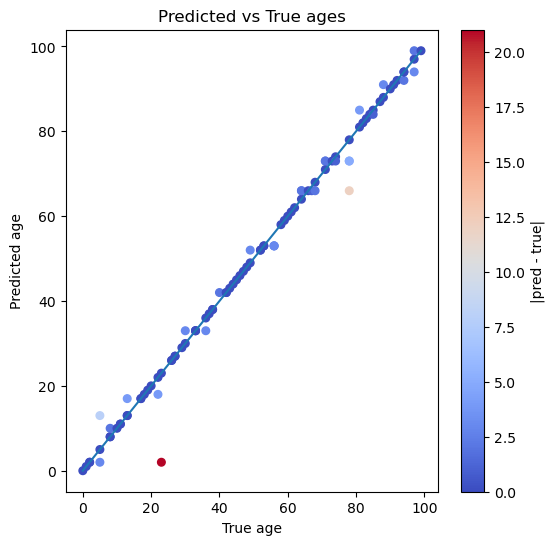

In [7]:
plot_concentration(results['true'], results['pred'], results['errors'])

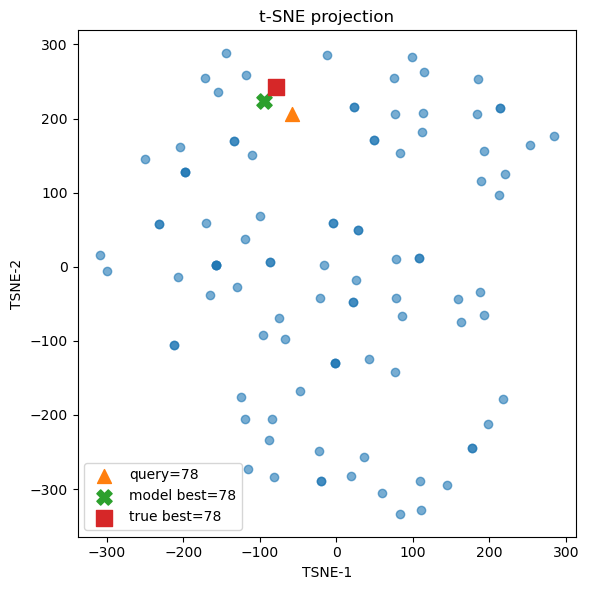

In [6]:
plot_tsne(78,
          sentences=sentences,
          encoder=encoder,
          pca_dims=PCA_DIMS,
          perp=TSNE_PERPLEXITY
          )